## Import Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## Download Dataset & Config

In [2]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded to:", path)

base_directory = path
train, test = 'Training', 'Testing'
target_size = (224, 224)
random_state = 42
batch_size = 32
num_classes = 4
device = "cuda" if torch.cuda.is_available() else "cpu"

# label_map is the single source of truth for class order
label_map = {
    'notumor': 0,
    'glioma': 1,
    'meningioma': 2,
    'pituitary': 3
}
categories = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

print(f"Device      : {device}")
print(f"Categories  : {categories}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset
Device      : cuda
Categories  : ['notumor', 'glioma', 'meningioma', 'pituitary']


## Exploring the Data

In [3]:
actual_categories = os.listdir(os.path.join(base_directory, train))
print("Folders found:", actual_categories)
assert set(actual_categories) == set(categories), "Mismatch between label_map and actual folders!"

def display_images(dataset, num_images=4, image_size=(224, 224)):
    dataset_path = os.path.join(base_directory, dataset)
    fig, axes = plt.subplots(len(categories), num_images, figsize=(15, 3 * len(categories)))
    for i, cat in enumerate(categories):
        cat_path = os.path.join(dataset_path, cat)
        img_files = os.listdir(cat_path)[:num_images]
        for j, img_file in enumerate(img_files):
            img = Image.open(os.path.join(cat_path, img_file)).convert('RGB')
            img = img.resize(image_size)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(cat, fontsize=12)
    plt.suptitle(f"{dataset} Set - Sample Images", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_class_distribution(dataset):
    path = os.path.join(base_directory, dataset)
    counts = [len(os.listdir(os.path.join(path, cat))) for cat in categories]
    plt.figure(figsize=(6, 4))
    plt.bar(categories, counts, color='steelblue')
    plt.title(f"{dataset} Set - Class Distribution")
    plt.ylabel("Number of images")
    for i, c in enumerate(counts):
        plt.text(i, c + 5, str(c), ha='center')
    plt.show()

Folders found: ['pituitary', 'notumor', 'meningioma', 'glioma']


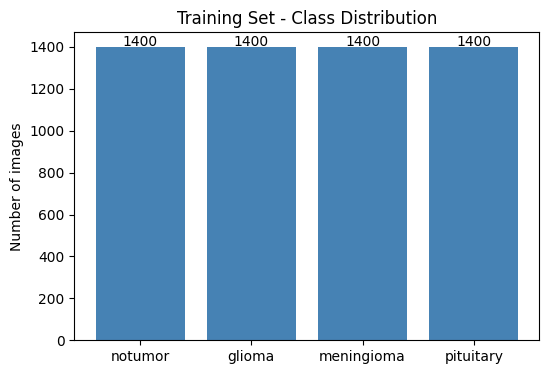

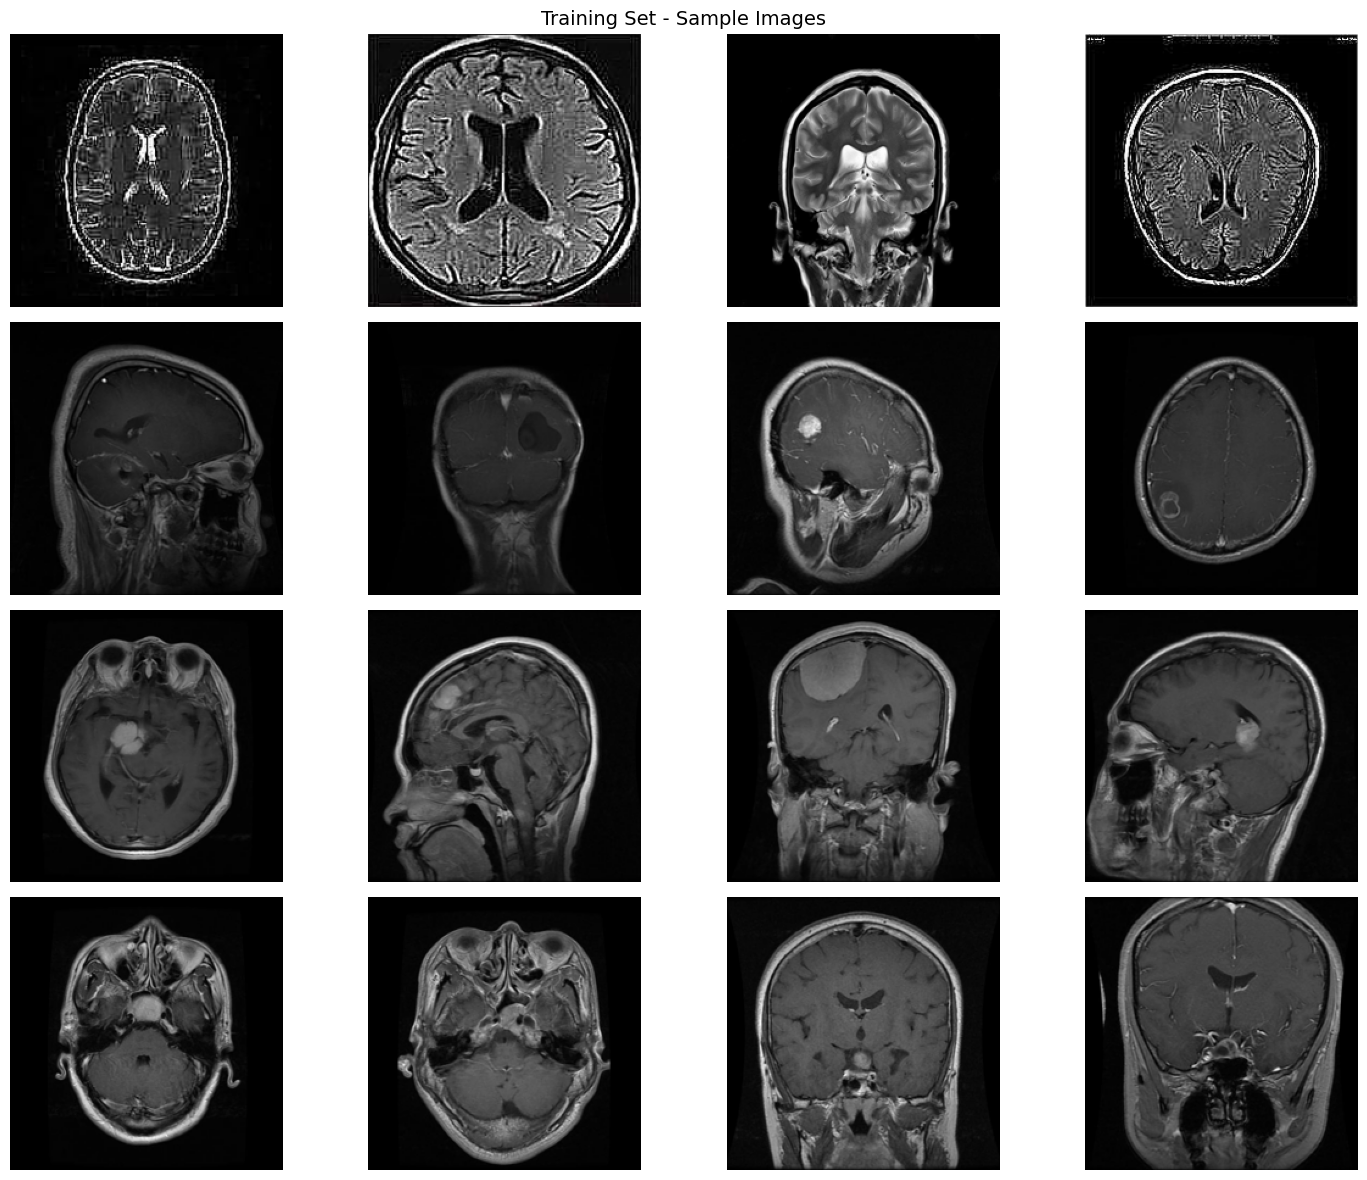

In [4]:
plot_class_distribution(train)
display_images(train)

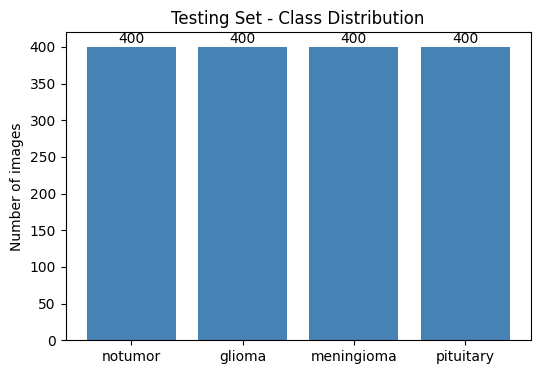

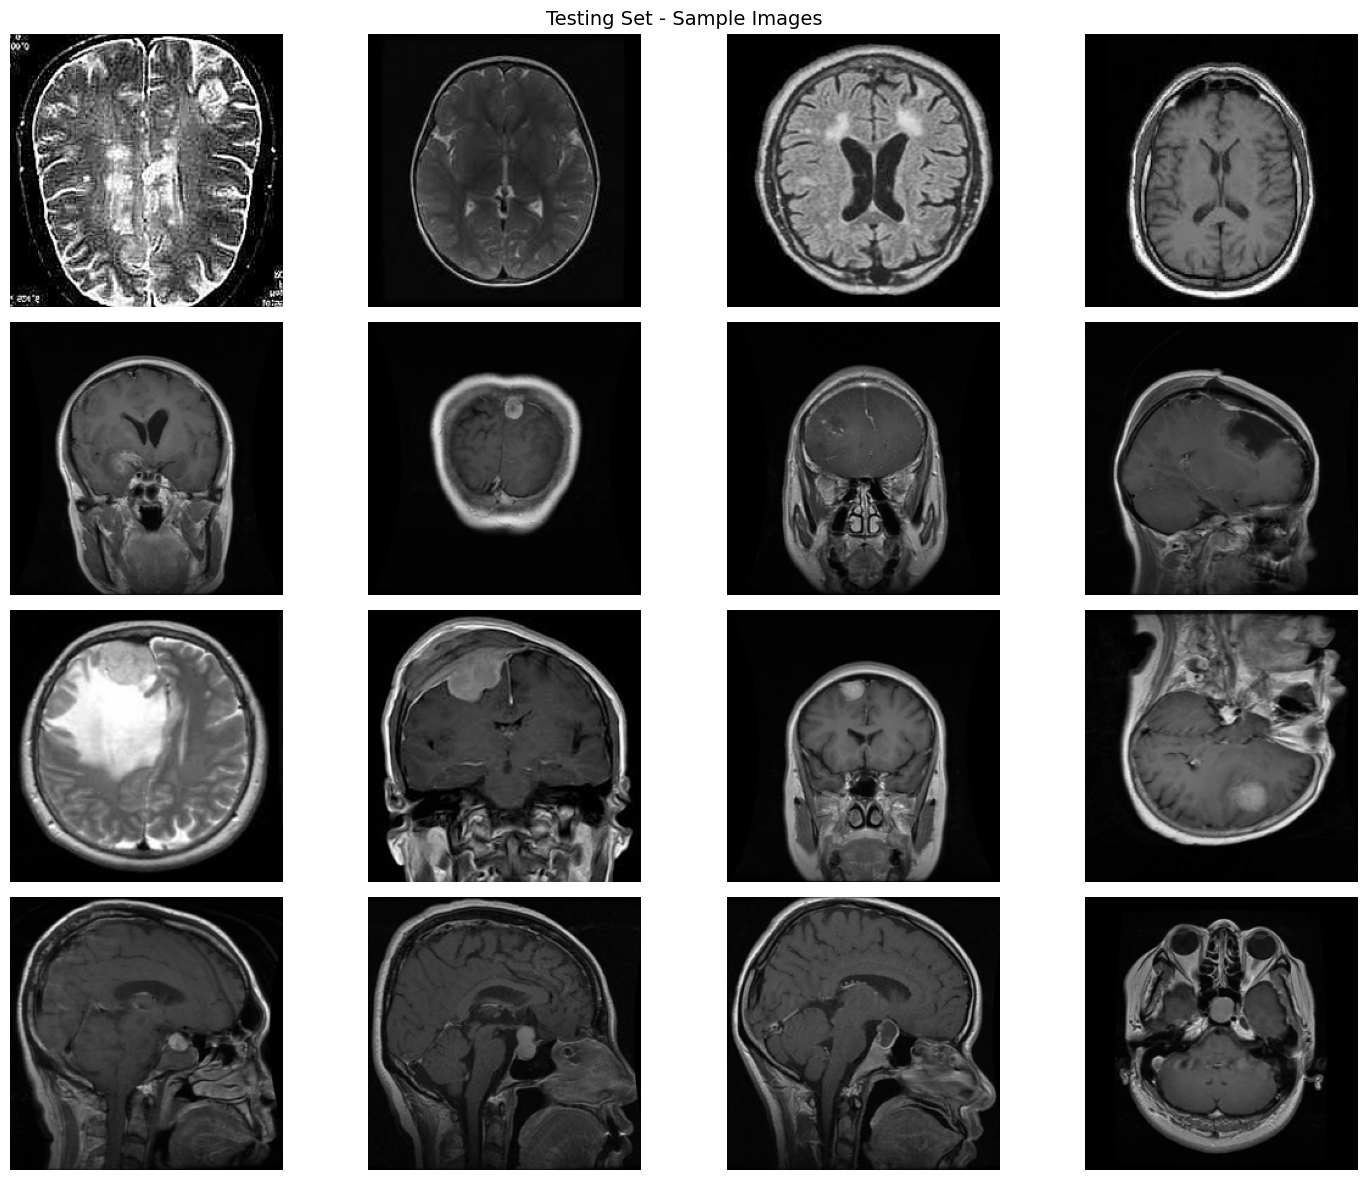

In [5]:
plot_class_distribution(test)
display_images(test)

## Preparing the Data

In [6]:
def create_dataset(path):
    my_list = []
    for category in categories:
        category_path = os.path.join(path, category)
        for file_name in os.listdir(category_path):
            file_path = os.path.join(category_path, file_name)
            if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                my_list.append([file_path, category])
    return pd.DataFrame(my_list, columns=['file_path', 'label'])

train_df = create_dataset(os.path.join(base_directory, train))
test_df = create_dataset(os.path.join(base_directory, test))

train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

print(f"Train samples: {len(train_df)}")
print(f"Test samples : {len(test_df)}")

Train samples: 5600
Test samples : 1600


### ImageDataset class

In [7]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

### Transforms & DataLoaders

In [8]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(target_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=(0.8, 1.2)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [9]:
test_df_split, val_df_split = train_test_split(
    test_df, test_size=0.5, random_state=random_state, stratify=test_df['label']
)
test_df_split = test_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df_split, transform=test_transform)
test_dataset = ImageDataset(test_df_split, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 5600 | Val: 800 | Test: 800


## Model 1 (Custom CNN)

In [10]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = BrainTumorCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

## Shared Training / Testing / Plotting Functions

In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=40, name='model', patience=15):
    model.to(device)
    best_val_acc = 0.0
    tolerance = 0
    TARGET_ACC = 99.0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Accuracy: {val_acc:.2f}%")
        print("#" * 80)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_brain_tumor_{name}.pth')
            tolerance = 0
            print(f" Best model saved (val_acc: {val_acc:.2f}%)")
        else:
            tolerance += 1
            print(f" No improvement. Patience: {tolerance}/{patience}")

        if train_acc >= TARGET_ACC and val_acc >= TARGET_ACC:
            print(f" Target reached - Train: {train_acc:.2f}% | Val: {val_acc:.2f}% - Stopping.")
            break

        if tolerance >= patience:
            if current_lr <= 1e-6:
                print(f" Early stopping: no improvement after {epoch+1} epochs and LR exhausted.")
                break
            else:
                print(" Patience hit but LR still has room - resetting patience counter.")
                tolerance = 0

    return history


def test_model(model, test_loader, categories):
    model.to(device)
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {test_acc:.2f}%\n")
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=categories))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return test_acc


def plot_training_history(history, model_name="model"):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout()
    plt.show()

### Train & Evaluate Model 1 (Custom CNN)

In [12]:
print("Starting training...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=40, name='customcnn', patience=15)

Starting training...
Epoch [1/40] | LR: 0.000700
Train Loss: 2.0221, Train Accuracy: 54.30%
Val   Loss: 1.0506, Val   Accuracy: 62.50%
################################################################################
 Best model saved (val_acc: 62.50%)
Epoch [2/40] | LR: 0.000700
Train Loss: 0.7900, Train Accuracy: 67.59%
Val   Loss: 1.0660, Val   Accuracy: 66.12%
################################################################################
 Best model saved (val_acc: 66.12%)
Epoch [3/40] | LR: 0.000700
Train Loss: 0.7037, Train Accuracy: 71.48%
Val   Loss: 0.8479, Val   Accuracy: 72.75%
################################################################################
 Best model saved (val_acc: 72.75%)
Epoch [4/40] | LR: 0.000700
Train Loss: 0.6164, Train Accuracy: 75.88%
Val   Loss: 1.0232, Val   Accuracy: 69.12%
################################################################################
 No improvement. Patience: 1/15
Epoch [5/40] | LR: 0.000700
Train Loss: 0.5636, Train Accur

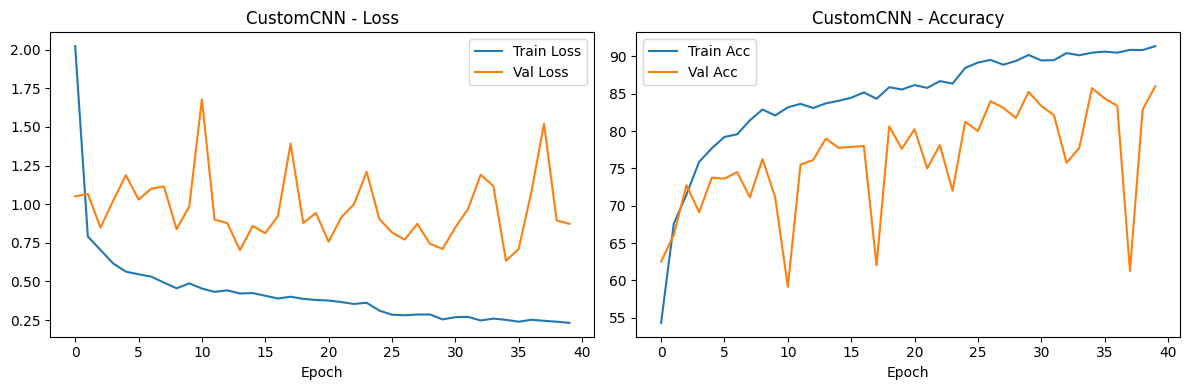

In [13]:
plot_training_history(history, model_name="CustomCNN")


Loading best model for testing...
Test Accuracy: 88.00%

Classification Report:

              precision    recall  f1-score   support

     notumor       0.81      1.00      0.89       200
      glioma       0.99      0.71      0.83       200
  meningioma       0.85      0.83      0.84       200
   pituitary       0.92      0.97      0.94       200

    accuracy                           0.88       800
   macro avg       0.89      0.88      0.88       800
weighted avg       0.89      0.88      0.88       800



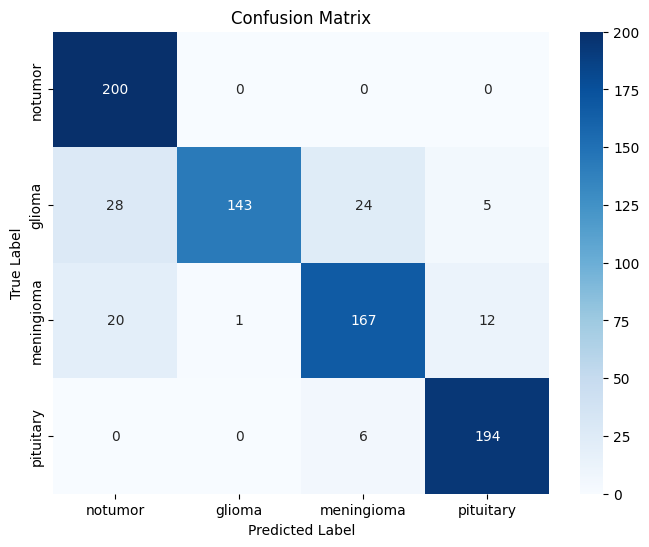

In [14]:
print("\nLoading best model for testing...")
model.load_state_dict(torch.load('best_brain_tumor_customcnn.pth'))
customcnn_acc = test_model(model, test_loader, categories)

## Model 2 (MobileNetV3-Large)


In [15]:
model2 = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)

for param in model2.parameters():
    param.requires_grad = False

num_ftrs = model2.classifier[-1].in_features
model2.classifier[-1] = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 4)
)

model2 = model2.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 124MB/s]


In [16]:
optimizer = optim.Adam(model2.classifier.parameters(), lr=0.001)

### Train & Evaluate Model 2 (MobileNetV3-Large)

In [17]:
print("Starting training...")
history2 = train_model(model2, train_loader, val_loader, criterion, optimizer, num_epochs=40, name='mobilenetv3', patience=15)

Starting training...
Epoch [1/40] | LR: 0.001000
Train Loss: 0.4576, Train Accuracy: 82.52%
Val   Loss: 0.6436, Val   Accuracy: 79.00%
################################################################################
 Best model saved (val_acc: 79.00%)
Epoch [2/40] | LR: 0.001000
Train Loss: 0.3350, Train Accuracy: 87.20%
Val   Loss: 0.7833, Val   Accuracy: 73.25%
################################################################################
 No improvement. Patience: 1/15
Epoch [3/40] | LR: 0.001000
Train Loss: 0.2980, Train Accuracy: 88.98%
Val   Loss: 0.6032, Val   Accuracy: 81.62%
################################################################################
 Best model saved (val_acc: 81.62%)
Epoch [4/40] | LR: 0.001000
Train Loss: 0.2840, Train Accuracy: 88.91%
Val   Loss: 0.5448, Val   Accuracy: 85.75%
################################################################################
 Best model saved (val_acc: 85.75%)
Epoch [5/40] | LR: 0.001000
Train Loss: 0.2635, Train Accur

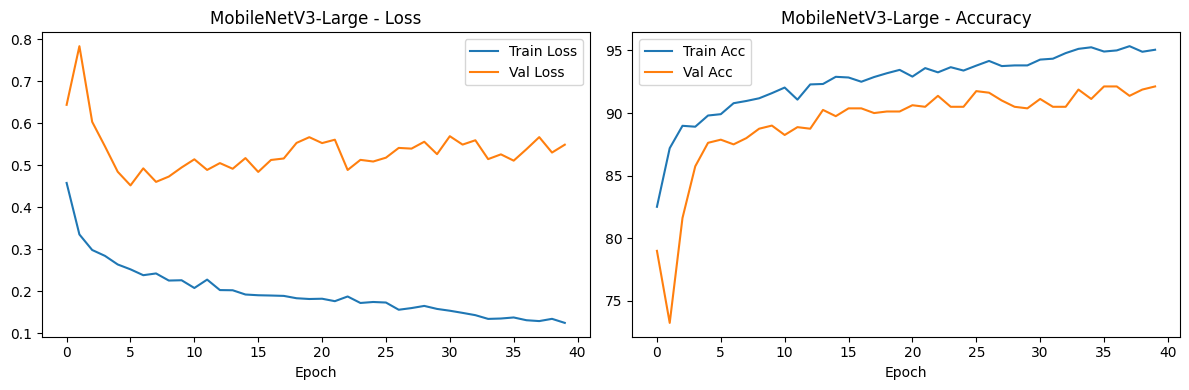

In [18]:
plot_training_history(history2, model_name="MobileNetV3-Large")


Loading best model for testing...
Test Accuracy: 92.50%

Classification Report:

              precision    recall  f1-score   support

     notumor       0.91      1.00      0.95       200
      glioma       0.95      0.78      0.86       200
  meningioma       0.87      0.93      0.90       200
   pituitary       0.98      0.99      0.99       200

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.92       800
weighted avg       0.93      0.93      0.92       800



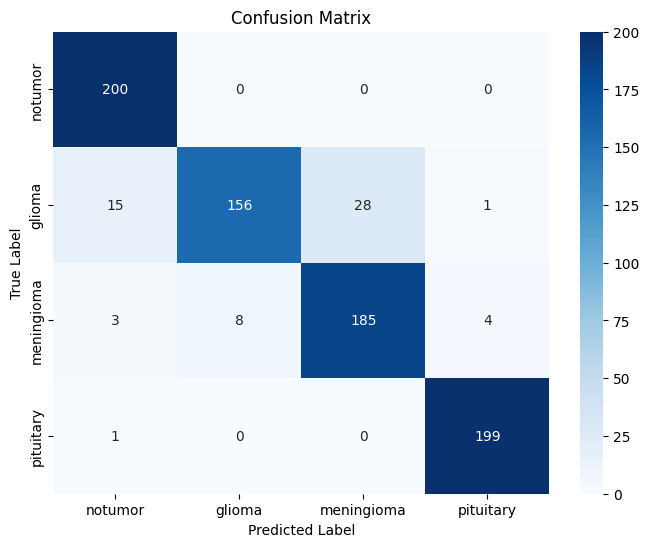

In [19]:
print("\nLoading best model for testing...")
model2.load_state_dict(torch.load('best_brain_tumor_mobilenetv3.pth'))
mobilenet_acc = test_model(model2, test_loader, categories)

## Model 3 (EfficientNet-V2-S)

In [20]:
effv2_train_transform = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

effv2_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

effv2_train_dataset = ImageDataset(train_df, transform=effv2_train_transform)
effv2_val_dataset = ImageDataset(val_df_split, transform=effv2_test_transform)
effv2_test_dataset = ImageDataset(test_df_split, transform=effv2_test_transform)

effv2_train_loader = DataLoader(effv2_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
effv2_val_loader = DataLoader(effv2_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
effv2_test_loader = DataLoader(effv2_test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [21]:
def mixup_data(images, labels, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    random_index = torch.randperm(images.size(0)).to(images.device)
    mixed_images = lam * images + (1 - lam) * images[random_index]
    labels_a, labels_b = labels, labels[random_index]
    return mixed_images, labels_a, labels_b, lam

In [22]:
def build_efficientnet_v2s(num_classes=4):
    model = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
    print("EfficientNet-V2-S loaded")

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    for name, param in model.named_parameters():
        if any(layer in name for layer in ['features.7', 'features.6', 'classifier']):
            param.requires_grad = True

    return model.to(device)

model3 = build_efficientnet_v2s(num_classes=4)

trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model3.parameters())
frozen_params = total_params - trainable_params
print(f"Trainable: {trainable_params:,} | Frozen: {frozen_params:,} | Total: {total_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 112MB/s]


EfficientNet-V2-S loaded
Trainable: 15,551,020 | Frozen: 5,285,416 | Total: 20,836,436


In [23]:
BASE_LR = 2e-4
optimizer3 = optim.AdamW([
    {'params': [p for n, p in model3.named_parameters() if 'features.6' in n and p.requires_grad], 'lr': BASE_LR * 0.05},
    {'params': [p for n, p in model3.named_parameters() if 'features.7' in n and p.requires_grad], 'lr': BASE_LR * 0.2},
    {'params': [p for n, p in model3.named_parameters() if 'classifier' in n and p.requires_grad], 'lr': BASE_LR},
], weight_decay=1e-4)

In [24]:
BEST_MODEL_PATH = 'best_brain_tumor_effv2s.pth'

def train_effv2s(model, train_loader, val_loader, criterion, optimizer, num_epochs=40, patience=15, mixup_alpha=0.4):
    model.to(device)
    best_val_acc = 0.0
    tolerance = 0
    TARGET_ACC = 99.0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            mixed_images, labels_a, labels_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
            outputs = model(mixed_images)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (lam * (predicted == labels_a).sum().item()
                              + (1 - lam) * (predicted == labels_b).sum().item())

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Accuracy: {val_acc:.2f}%")
        print("#" * 80)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            tolerance = 0
            print(f" Best model saved (val_acc: {val_acc:.2f}%)")
        else:
            tolerance += 1
            print(f" No improvement. Patience: {tolerance}/{patience}")

        if train_acc >= TARGET_ACC and val_acc >= TARGET_ACC:
            print(" Target reached - stopping.")
            break

        if tolerance >= patience:
            if current_lr <= 1e-6:
                print(" Early stopping: no improvement and LR exhausted.")
                break
            else:
                print(" Patience hit but LR still has room - resetting patience counter.")
                tolerance = 0

    return history

### Train & Evaluate Model 3 (EfficientNet-V2-S)

In [26]:
print("\n" + "-"*70)
print(" MODEL 3 : EfficientNet-V2-S")
print("-"*70)
print("Starting training...")

history3 = train_effv2s(
    model=model3,
    train_loader=effv2_train_loader,
    val_loader=effv2_val_loader,
    criterion=criterion,
    optimizer=optimizer3,
    num_epochs=40,
    patience=15
)


----------------------------------------------------------------------
 MODEL 3 : EfficientNet-V2-S
----------------------------------------------------------------------
Starting training...
Epoch [1/40] | LR: 0.000010
Train Loss: 0.7007, Train Accuracy: 75.79%
Val   Loss: 0.4453, Val   Accuracy: 85.12%
################################################################################
 Best model saved (val_acc: 85.12%)
Epoch [2/40] | LR: 0.000010
Train Loss: 0.6666, Train Accuracy: 76.89%
Val   Loss: 1.5932, Val   Accuracy: 85.38%
################################################################################
 Best model saved (val_acc: 85.38%)
Epoch [3/40] | LR: 0.000010
Train Loss: 0.6326, Train Accuracy: 78.57%
Val   Loss: 0.8777, Val   Accuracy: 85.25%
################################################################################
 No improvement. Patience: 1/15
Epoch [4/40] | LR: 0.000010
Train Loss: 0.6168, Train Accuracy: 79.04%
Val   Loss: 5.2160, Val   Accuracy: 87.38%
####

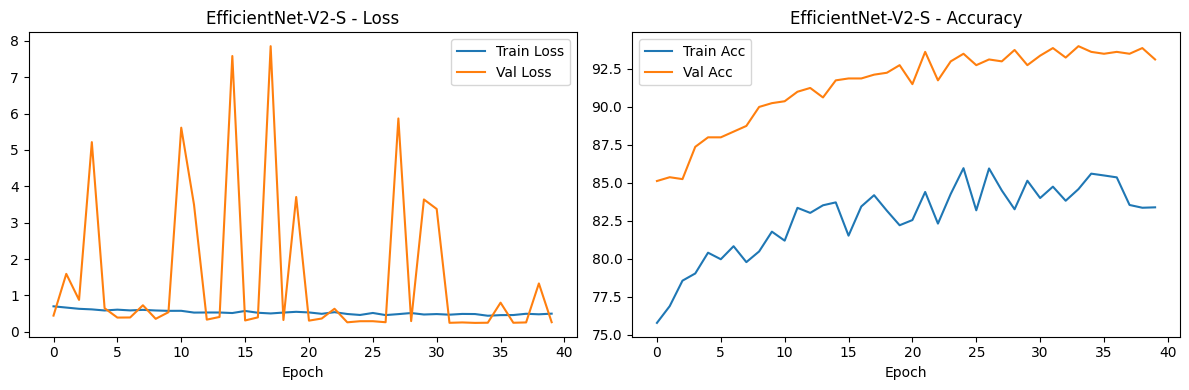

In [27]:
plot_training_history(history3, model_name="EfficientNet-V2-S")


Loading best model for testing...
Test Accuracy: 92.88%

Classification Report:

              precision    recall  f1-score   support

     notumor       0.92      1.00      0.96       200
      glioma       0.93      0.86      0.90       200
  meningioma       0.89      0.93      0.90       200
   pituitary       0.98      0.93      0.95       200

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



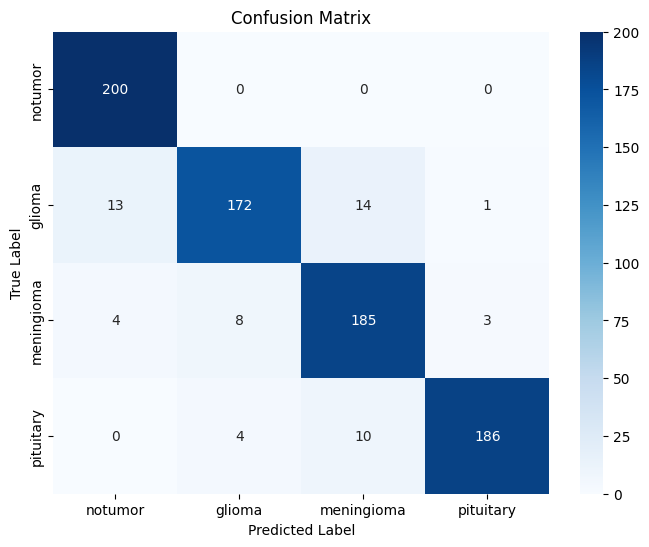

In [28]:
print("\nLoading best model for testing...")
model3.load_state_dict(torch.load(BEST_MODEL_PATH))
effv2s_acc = test_model(model3, effv2_test_loader, categories)

## Model Comparison

            Model  Test Accuracy (%)  Approx. Params (M)
 EfficientNetV2-S             92.875           20.836436
MobileNetV3-Large             92.500            4.860980
       Custom CNN             88.000           26.082052


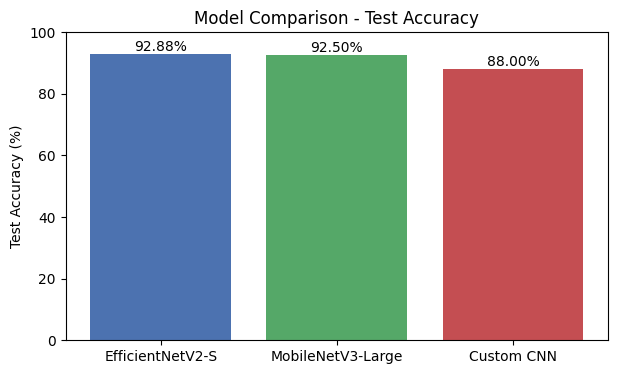

In [29]:
results_df = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV3-Large', 'EfficientNetV2-S'],
    'Test Accuracy (%)': [customcnn_acc, mobilenet_acc, effv2s_acc],
    'Approx. Params (M)': [
        sum(p.numel() for p in model.parameters()) / 1e6,
        sum(p.numel() for p in model2.parameters()) / 1e6,
        sum(p.numel() for p in model3.parameters()) / 1e6,
    ]
})
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(results_df['Model'], results_df['Test Accuracy (%)'], color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylabel('Test Accuracy (%)')
plt.title('Model Comparison - Test Accuracy')
plt.ylim(0, 100)
for i, acc in enumerate(results_df['Test Accuracy (%)']):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center')
plt.show()

## Deployment - Save Final Model & Predict Function

In [30]:
DEPLOY_PATH = 'brain_tumor_effv2s_final.pth'

torch.save({
    'model_name': 'efficientnet_v2_s',
    'num_classes': num_classes,
    'categories': categories,
    'label_map': label_map,
    'state_dict': model3.state_dict(),
}, DEPLOY_PATH)

print(f"Model saved to {DEPLOY_PATH}")

Model saved to brain_tumor_effv2s_final.pth


In [31]:
def predict_single_image(image_path):
    checkpoint = torch.load(DEPLOY_PATH, map_location=device)
    loaded_model = build_efficientnet_v2s(num_classes=checkpoint['num_classes'])
    loaded_model.load_state_dict(checkpoint['state_dict'])
    loaded_model.eval()
    class_names = checkpoint['categories']

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])

    image = Image.open(image_path).convert('RGB')
    tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(loaded_model(tensor), dim=1).squeeze().cpu().numpy()

    predicted_idx = np.argmax(probs)

    print(f"\n{'='*45}")
    print(f" Predicted Class : {class_names[predicted_idx]}")
    print(f" Confidence      : {probs[predicted_idx]*100:.1f}%")
    print(f"{'='*45}")
    print("\n All class probabilities:")
    for name, prob in zip(class_names, probs):
        bar = '█' * int(prob * 40)
        print(f"  {name:<12} {bar}  {prob*100:.1f}%")

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted: {class_names[predicted_idx]}\nConfidence: {probs[predicted_idx]*100:.1f}%", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return class_names[predicted_idx], probs

EfficientNet-V2-S loaded

 Predicted Class : notumor
 Confidence      : 82.7%

 All class probabilities:
  notumor      █████████████████████████████████  82.7%
  glioma       █████  13.1%
  meningioma   █  3.7%
  pituitary      0.5%


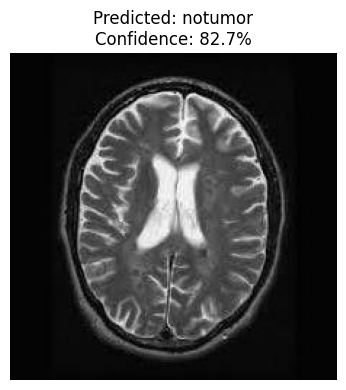

In [32]:
# Example: predict on a random image from the test set
sample_path = test_df.sample(1, random_state=1)['file_path'].values[0]
predicted_class, probabilities = predict_single_image(sample_path)